# Prerequisites
Importing necessary libraries and datasets.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from lightgbm import LGBMRegressor
from skforecast.direct import ForecasterDirect
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# os.getcwd()
data = pd.read_csv('datasets/final-data.csv')
# data.info()

# Data Preprocessing
Determining features and labels, splitting data for train and testing.

In [2]:
y = data['Sales']
# print(y)

In [3]:
exog = data.drop(columns=['DayName','NormDate'])
# exog.info()

# Model engineering
Detemining horizon and hyperparameters. Defining, training, testing and evaluating model.

In [4]:
# forecast horizon
steps = 100

# auto lags for 30 days
lags = 30

# data on the first 100 days will be used for model training
train_size = 400

if (train_size < 130):
    raise SystemExit('Minimal train data size is at least 130 rows!')
else:
    # split data for training and testing
    y_train, y_test = y[:train_size], y[train_size:]
    x_train, x_test = exog[:train_size], exog[train_size:]

    # datas = [y_train, y_test, x_train, x_test]

    # for data in datas:
    #     print(data.info(), end="\n\n")

In [5]:
forecaster = ForecasterDirect(
    regressor= LGBMRegressor(
        n_estimators=500,
        learning_rate=0.01,
        subsample=0.9,
        colsample_bytree=0.9
    ),
    steps=steps,
    lags=lags
)
# forecaster

In [6]:
forecaster.fit(
    y=y_train,
    exog=x_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000317 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4983
[LightGBM] [Info] Number of data points in the train set: 271, number of used features: 59
[LightGBM] [Info] Start training from score 34141.568830
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [7]:
preds = forecaster.predict(
    steps=steps,
    exog=x_test
)
# preds = pd.DataFrame(preds).reset_index(drop=True)
# preds

In [8]:
mae = mean_absolute_error(y_test[:steps], preds)
rmse = root_mean_squared_error(y_test[:steps], preds)

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

MAE : 1116.54
RMSE : 1941.04


In [9]:
y_steps = y_test[:steps]
y_steps = pd.DataFrame(y_steps)
y_steps['Pred_Sales'] = preds
y_steps.reset_index(inplace=True)
y_steps = y_steps.rename(columns={"index":"day"})

In [10]:
df_observed = pd.DataFrame({
    "day" : np.arange(0, y.count()),
    "sales" : y,
    "label" : "Observed Sales"
})

df_predicted = pd.DataFrame({
    "day" : y_steps['day'],
    "sales" : y_steps['Pred_Sales'],
    "label" : "Predicted Sales"
})

df_eval = pd.concat([df_observed[(train_size-30):(y_train.count()+steps)], df_predicted], ignore_index=True)

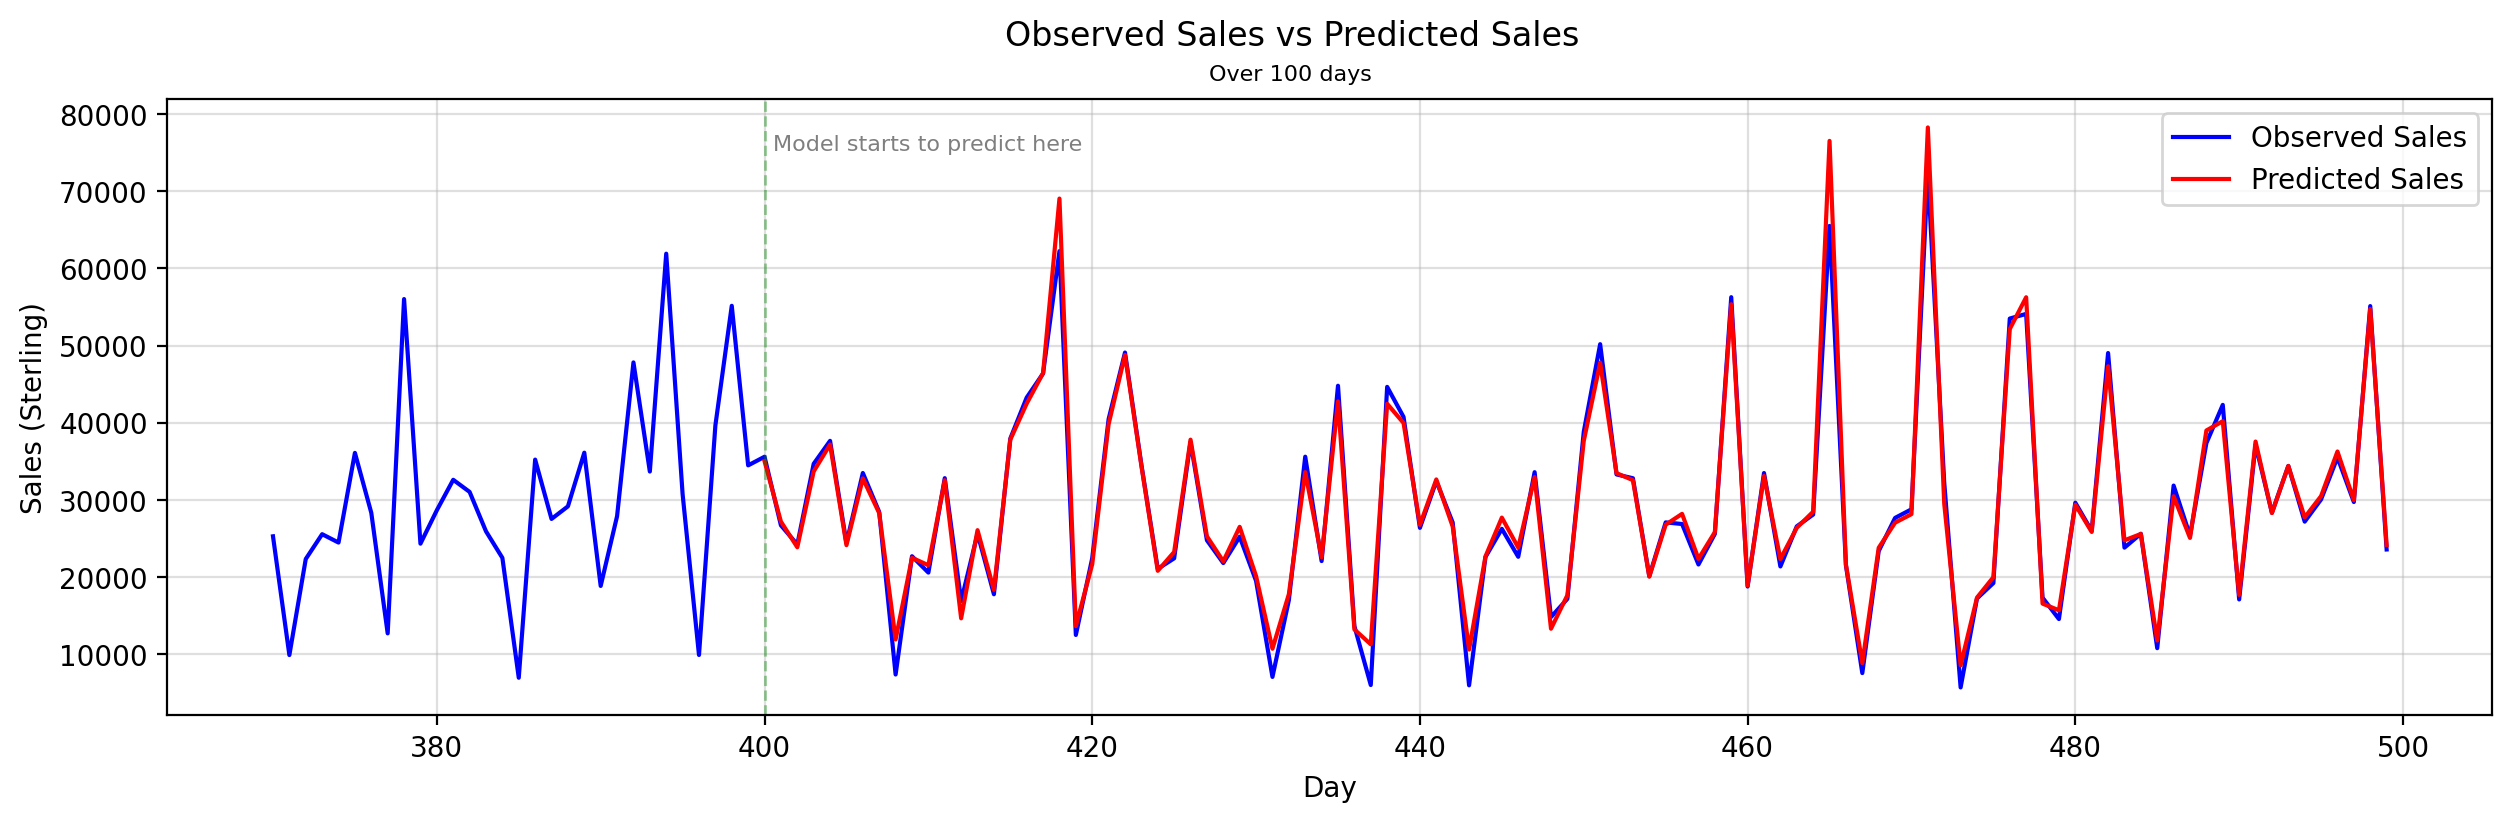

In [11]:
plt.figure(figsize=(15,4), dpi=200)
sns.lineplot(
    data=df_eval,
    x="day",
    y="sales",
    hue='label',
    palette={'Observed Sales':'blue', 'Predicted Sales':'red'}
)
plt.grid(axis="both", alpha=0.4)
plt.suptitle('Observed Sales vs Predicted Sales')
plt.title(f'Over {steps} days', fontsize=8, loc="center", pad=7, x=0.483)
plt.ylabel('Sales (Sterling)')
plt.xlabel('Day')
plt.legend(title=None)
plt.axvline(x=train_size, color='green', ls='--', lw='1', alpha=0.4)
y_min, y_max = plt.ylim()
plt.text(x=train_size+0.5, y=y_max*0.92, s='Model starts to predict here', fontsize='8', alpha=0.5)
# plt.xticks(df_eval['day'].unique())
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000286 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4983
[LightGBM] [Info] Number of data points in the train set: 271, number of used features: 59
[LightGBM] [Info] Start training from score 18881.453875
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

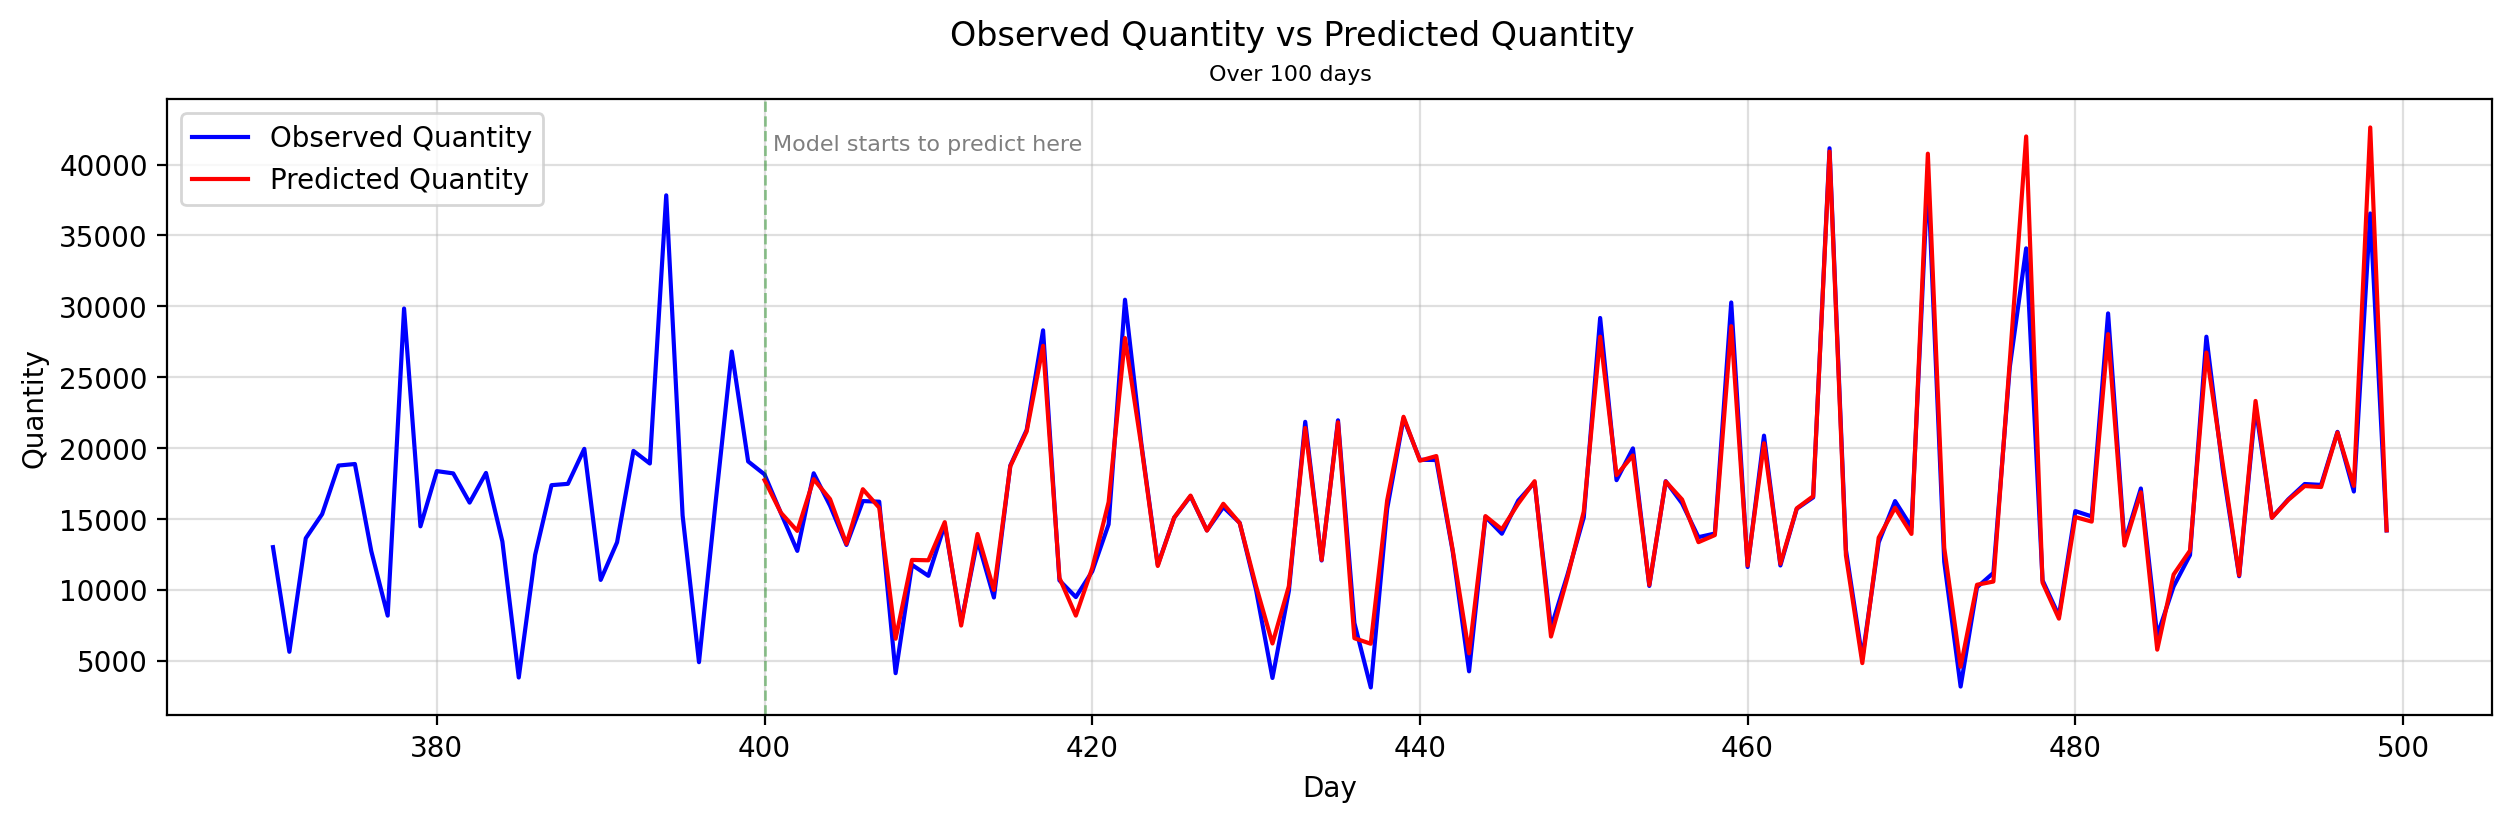

In [12]:
# determining label
y = data['Quantity']

# forecast horizon
steps = 100

# auto lags for 30 days
lags = 30

# data on the first 100 days will be used for model training
train_size = 400

if (train_size < 130):
    raise SystemExit('Minimal train data size is at least 130 rows!')
else:
    # split data for training and testing
    y_train, y_test = y[:train_size], y[train_size:]
    x_train, x_test = exog[:train_size], exog[train_size:]

    # datas = [y_train, y_test, x_train, x_test]

    # for data in datas:
    #     print(data.info(), end="\n\n")
    
forecaster = ForecasterDirect(
    regressor= LGBMRegressor(
        n_estimators=500,
        learning_rate=0.01,
        subsample=0.9,
        colsample_bytree=0.9
    ),
    steps=steps,
    lags=lags
)

forecaster.fit(
    y=y_train,
    exog=x_train
)

preds = forecaster.predict(
    steps=steps,
    exog=x_test
)

mae = mean_absolute_error(y_test[:steps], preds)
rmse = root_mean_squared_error(y_test[:steps], preds)

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

y_steps = y_test[:steps]
y_steps = pd.DataFrame(y_steps)
y_steps['Pred_Quantity'] = preds
y_steps.reset_index(inplace=True)
y_steps = y_steps.rename(columns={"index":"day"})

df_observed = pd.DataFrame({
    "day" : np.arange(0, y.count()),
    "quantity" : y,
    "label" : "Observed Quantity"
})

df_predicted = pd.DataFrame({
    "day" : y_steps['day'],
    "quantity" : y_steps['Pred_Quantity'],
    "label" : "Predicted Quantity"
})

df_eval = pd.concat([df_observed[(train_size-30):(y_train.count()+steps)], df_predicted], ignore_index=True)

plt.figure(figsize=(15,4), dpi=200)
sns.lineplot(
    data=df_eval,
    x="day",
    y="quantity",
    hue='label',
    palette={'Observed Quantity':'blue', 'Predicted Quantity':'red'}
)
plt.grid(axis="both", alpha=0.4)
plt.suptitle('Observed Quantity vs Predicted Quantity')
plt.title(f'Over {steps} days', fontsize=8, loc="center", pad=7, x=0.483)
plt.ylabel('Quantity')
plt.xlabel('Day')
plt.legend(title=None)
plt.axvline(x=train_size, color='green', ls='--', lw='1', alpha=0.4)
y_min, y_max = plt.ylim()
plt.text(x=train_size+0.5, y=y_max*0.92, s='Model starts to predict here', fontsize='8', alpha=0.5)
# plt.xticks(df_eval['day'].unique())
plt.show()

In [1]:
print('miaw')

miaw
